In [ ]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 10.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993222 sha256=94913ba10c4c2901d5a2a362a61291b10f6aa1e7dad8f070158389833b15be91
  Stored in directory: /root/.cache/pip/wheels/0a/f2/b2/e5ca405801e05eb7c8ed5b3b4bcf1fcabcd6272c167640072e
Successfully built langdetect


In [ ]:
import pandas as pd
pd.options.mode.chained_assignment = None

import re
import csv
import nltk
import string
import numpy as np
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from nltk import pos_tag
from textblob import TextBlob
from imblearn.over_sampling import SMOTE
from langdetect import detect, DetectorFactory
from langdetect.lang_detect_exception import LangDetectException
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.corpus.reader.wordnet import NOUN, VERB, ADJ, ADV
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from joblib import dump, load
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

# **LOAD MODEL**

In [ ]:
clean_df = pd.read_csv('/content/application_review.csv')

# **TEXT PREPROCESSING**

In [ ]:
def detect_language(text):
    try:
        return detect(text)
    except LangDetectException:
        return 'unknown'

clean_df['detected_language'] = clean_df['review'].apply(lambda x: detect_language(x) if isinstance(x, str) else 'unknown')
clean_df = clean_df[clean_df['detected_language'] == 'en']

In [ ]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text)
    text = re.sub(r'#[A-Za-z0-9]+', '', text)
    text = re.sub(r'RT[\s]', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[0-9]+', '', text)
    text = text.replace('\n', ' ')
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def remove_emoji(text):
    if isinstance(text, str):
        return text.encode('ascii', 'ignore').decode('ascii')
    return text

def caseFoldingText(text):
    text = text.lower()
    return text

def tokenizeText(text):
    text = word_tokenize(text)
    return text

custom_stopwords = set(stopwords.words('english')).union({"app", "use", "great", "get", "would"})
def filteringText(text):
    filtered = [txt for txt in text if txt and txt not in custom_stopwords]
    return filtered

def lemmatizeText(text):
    lemmatizer = WordNetLemmatizer()
    def get_wordnet_pos(word):
        tag = pos_tag([word])[0][1][0].upper()
        tag_dict = {'J': ADJ, 'N': NOUN, 'V': VERB, 'R': ADV}
        return tag_dict.get(tag, NOUN)

    lemmatized_words = [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in text]
    return lemmatized_words

def toSentence(list_words):
    sentence = ' '.join(word for word in list_words)
    return sentence

slangwords = {
    r'\b@\b': "at",
    r'\bwtb\b': "want to buy",
    r'\bwts\b': "want to sell",
    r'\bbgt\b': "really",
    r'\bmaks\b': "maximum",
    r'\bu\b': "you",
    r'\br\b': "are",
    r'\bthx\b': "thanks",
    r'\bpls\b': "please",
    r'\btbh\b': "to be honest",
    r'\bidk\b': "I don't know",
    r'\bbtw\b': "by the way",
    r'\bafaik\b': "as far as I know",
    r'\bimo\b': "in my opinion"
}

def slangWords(text):
    for slang, replacement in slangwords.items():
        text = re.sub(slang, replacement, text, flags=re.IGNORECASE)
    return text

In [ ]:
clean_df['content_no_emoji'] = clean_df['review'].apply(remove_emoji)
clean_df['text_clean'] = clean_df['content_no_emoji'].apply(cleaningText)
clean_df['text_caseFoldingText'] = clean_df['text_clean'].apply(caseFoldingText)
clean_df['text_slangWords'] = clean_df['text_caseFoldingText'].apply(slangWords)
clean_df['text_tokenizeText'] = clean_df['text_slangWords'].apply(tokenizeText)
clean_df['text_filteringText'] = clean_df['text_tokenizeText'].apply(filteringText)
clean_df['final_text'] = clean_df['text_filteringText'].apply(toSentence)

In [ ]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 75030 entries, 0 to 94520
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   review                75030 non-null  object
 1   detected_language     75030 non-null  object
 2   content_no_emoji      75030 non-null  object
 3   text_clean            75030 non-null  object
 4   text_caseFoldingText  75030 non-null  object
 5   text_slangWords       75030 non-null  object
 6   text_tokenizeText     75030 non-null  object
 7   text_filteringText    75030 non-null  object
 8   final_text            75030 non-null  object
dtypes: object(9)
memory usage: 5.7+ MB


In [ ]:
clean_df

,review,detected_language,content_no_emoji,text_clean,text_caseFoldingText,text_slangWords,text_tokenizeText,text_filteringText,final_text
0,Unbelievably laggier and laggier as you go dee...,en,Unbelievably laggier and laggier as you go dee...,Unbelievably laggier and laggier as you go dee...,unbelievably laggier and laggier as you go dee...,unbelievably laggier and laggier as you go dee...,"[unbelievably, laggier, and, laggier, as, you,...","[unbelievably, laggier, laggier, go, deeper, m...",unbelievably laggier laggier go deeper menus m...
1,Edited from prev versions: It's a decent app. ...,en,Edited from prev versions: It's a decent app. ...,Edited from prev versions Its a decent app I c...,edited from prev versions its a decent app i c...,edited from prev versions its a decent app i c...,"[edited, from, prev, versions, its, a, decent,...","[edited, prev, versions, decent, download, che...",edited prev versions decent download check sto...
2,"Most things it does fine, checking trophies, r...",en,"Most things it does fine, checking trophies, r...",Most things it does fine checking trophies rec...,most things it does fine checking trophies rec...,most things it does fine checking trophies rec...,"[most, things, it, does, fine, checking, troph...","[things, fine, checking, trophies, recent, gam...",things fine checking trophies recent games etc...
3,Could use some work. Uploaded 2 files (a video...,en,Could use some work. Uploaded 2 files (a video...,Could use some work Uploaded files a video cli...,could use some work uploaded files a video cli...,could use some work uploaded files a video cli...,"[could, use, some, work, uploaded, files, a, v...","[could, work, uploaded, files, video, clip, sc...",could work uploaded files video clip screensho...
4,This app has some annoying bugs... It will rep...,en,This app has some annoying bugs... It will rep...,This app has some annoying bugs It will repeat...,this app has some annoying bugs it will repeat...,this app has some annoying bugs it will repeat...,"[this, app, has, some, annoying, bugs, it, wil...","[annoying, bugs, repeat, notification, randoml...",annoying bugs repeat notification randomly day...
...,...,...,...,...,...,...,...,...,...
94455,I like this app,en,I like this app,I like this app,i like this app,i like this app,"[i, like, this, app]",[like],like
94456,Thank you,en,Thank you,Thank you,thank you,thank you,"[thank, you]",[thank],thank
94459,Play station,en,Play station,Play station,play station,play station,"[play, station]","[play, station]",play station
94460,PS5 Station,en,PS5 Station,PS Station,ps station,ps station,"[ps, station]","[ps, station]",ps station


# **FEATURE EXTRACTION & LABELLING**

In [ ]:
# Analyze Sentiment Using TextBlob & Do Labelling
def get_sentiment(text):
    analysis = TextBlob(text)
    if analysis.sentiment.polarity > 0:
        return 'positive'
    elif analysis.sentiment.polarity < 0:
        return 'negative'
    else:
        return 'neutral'

clean_df['sentiment'] = clean_df['final_text'].apply(get_sentiment)
clean_df['sentiment'] = clean_df['sentiment'].map({'positive': 1, 'neutral': 0, 'negative': -1})
print(clean_df['sentiment'].value_counts())

# Do Vectorization Using TF-IDF
vectorizer = TfidfVectorizer(max_features=10000, stop_words='english')
X = vectorizer.fit_transform(clean_df['final_text'])

sentiment
 1    34376
 0    25565
-1    15089
Name: count, dtype: int64


In [ ]:
# Undersampling
target_negative = 12700
target_positive = 12700
target_neutral = 11700

negative_df = clean_df[clean_df['sentiment'] == -1]
positive_df = clean_df[clean_df['sentiment'] == 1]
neutral_df = clean_df[clean_df['sentiment'] == 0]

negative_sampled = negative_df.sample(n=target_negative, random_state=42)
positive_sampled = positive_df.sample(n=target_positive, random_state=42)
neutral_sampled = neutral_df.sample(n=target_neutral, random_state=42)

balanced_df = pd.concat([negative_sampled, positive_sampled, neutral_sampled])
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)
balanced_df['sentiment'].value_counts()

,count
sentiment,
-1,12700
1,12700
0,11700


In [ ]:
# Split Dataset
X = balanced_df['final_text']
y = balanced_df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

print(f"Jumlah data train: {len(X_train)}")
print(f"Jumlah data validation: {len(X_val)}")
print(f"Jumlah data test: {len(X_test)}")

Jumlah data train: 23744
Jumlah data validation: 5936
Jumlah data test: 7420


In [ ]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"X_train_tfidf: {X_train_tfidf.dtype}")
print(f"X_test_tfidf: {X_test_tfidf.dtype}")

X_train_tfidf: float64
X_test_tfidf: float64


In [ ]:
print(X_train_tfidf.dtype)
print(X_test_tfidf.dtype)
print(y_train.dtypes)
print(y_test.dtypes)

float64
float64
int64
int64


# **MODEL TRAINING**

In [ ]:
# Random Forest
random_forest = RandomForestClassifier(random_state=42)
random_forest.fit(X_train_tfidf.toarray(), y_train)

X_val_tfidf = vectorizer.transform(X_val)

y_pred_train_rf = random_forest.predict(X_train_tfidf.toarray())
y_pred_val_rf = random_forest.predict(X_val_tfidf.toarray())
y_pred_test_rf = random_forest.predict(X_test_tfidf.toarray())

accuracy_train_rf = accuracy_score(y_train, y_pred_train_rf)
accuracy_val_rf = accuracy_score(y_val, y_pred_val_rf)
accuracy_test_rf = accuracy_score(y_test, y_pred_test_rf)

print('Random Forest - accuracy_train:', accuracy_train_rf)
print('Random Forest - accuracy_val:', accuracy_val_rf)
print('Random Forest - accuracy_test:', accuracy_test_rf)

Random Forest - accuracy_train: 0.9995982142857143
Random Forest - accuracy_val: 0.8955357142857143
Random Forest - accuracy_test: 0.9018571428571428


In [ ]:
# Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred_test_rf))

Classification Report:

              precision    recall  f1-score   support

          -1       0.89      0.90      0.90      2400
           0       0.88      0.96      0.92      2200
           1       0.94      0.85      0.89      2400

    accuracy                           0.90      7000
   macro avg       0.90      0.90      0.90      7000
weighted avg       0.90      0.90      0.90      7000



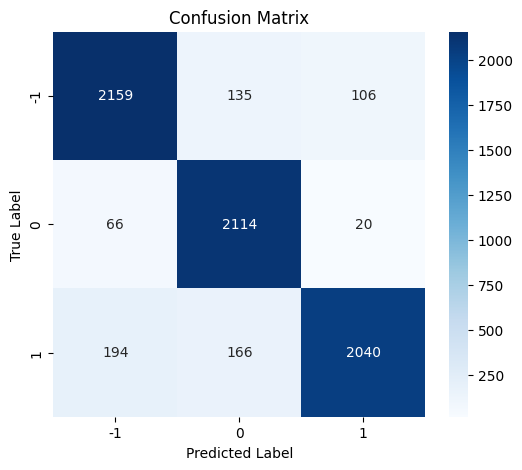

In [ ]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_test_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=[-1, 0, 1], yticklabels=[-1, 0, 1])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Save Model
dump(random_forest, 'random_forest_model.joblib')

['random_forest_model.joblib']

In [ ]:
# Logistic Regression
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_tfidf, y_train)

y_pred_train_lr = log_reg.predict(X_train_tfidf)
X_val_tfidf = vectorizer.transform(X_val)
y_pred_val_lr = log_reg.predict(X_val_tfidf)
y_pred_test_lr = log_reg.predict(X_test_tfidf)

accuracy_train_lr = accuracy_score(y_train, y_pred_train_lr)
accuracy_val_lr = accuracy_score(y_val, y_pred_val_lr)
accuracy_test_lr = accuracy_score(y_test, y_pred_test_lr)

print('Logistic Regression - accuracy_train:', accuracy_train_lr)
print('Logistic Regression - accuracy_val:', accuracy_val_lr)
print('Logistic Regression - accuracy_test:', accuracy_test_lr)

Logistic Regression - accuracy_train: 0.9463022237196765
Logistic Regression - accuracy_val: 0.9191374663072777
Logistic Regression - accuracy_test: 0.9210242587601079


In [ ]:
# Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred_test_lr))

Classification Report:

              precision    recall  f1-score   support

          -1       0.93      0.92      0.92      2540
           0       0.88      0.97      0.92      2340
           1       0.96      0.88      0.92      2540

    accuracy                           0.92      7420
   macro avg       0.92      0.92      0.92      7420
weighted avg       0.92      0.92      0.92      7420



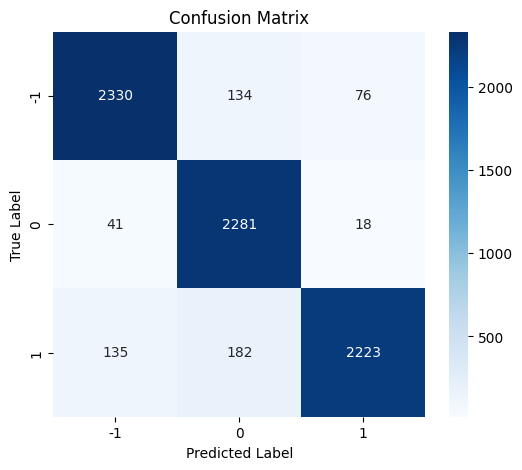

In [ ]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_test_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=[-1, 0, 1], yticklabels=[-1, 0, 1])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Save Model
dump(log_reg, 'log_reg_model.joblib')

['log_reg_model.joblib']

In [ ]:
# Encode Labels (From -1, 0, 1 To 0, 1, 2)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Splitting Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

# Tokenizing The Text
max_words = 20000
max_len = 100
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# Convert Text To Sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding Sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

# Build Model With L2 Regularization & Callbacks
l2_reg = 0.001

model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=True, kernel_regularizer=l2(l2_reg))),
    Dropout(0.3),
    Bidirectional(LSTM(32, kernel_regularizer=l2(l2_reg))),
    Dropout(0.3),
    Dense(32, activation='relu', kernel_regularizer=l2(l2_reg)),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

# Compile Model With First Learning Rate
initial_lr = 0.001
optimizer = Adam(learning_rate=initial_lr)
model.compile(loss='sparse_categorical_crossentropy',
              optimizer=optimizer,
              metrics=['accuracy'])

# Callbacks: Early Stopping & ReduceLROnPlateau
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)

# Training Model
epochs = 100
batch_size = 64

history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Model Evaluation
train_loss, train_acc = model.evaluate(X_train_pad, y_train, verbose=0)
val_loss, val_acc = model.evaluate(X_val_pad, y_val, verbose=0)
test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.5652 - loss: 1.1307 - val_accuracy: 0.9131 - val_loss: 0.3780 - learning_rate: 0.0010
Epoch 2/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9421 - loss: 0.2939 - val_accuracy: 0.9422 - val_loss: 0.2643 - learning_rate: 0.0010
Epoch 3/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.9759 - loss: 0.1671 - val_accuracy: 0.9431 - val_loss: 0.2432 - learning_rate: 0.0010
Epoch 4/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9792 - loss: 0.1348 - val_accuracy: 0.9466 - val_loss: 0.2406 - learning_rate: 0.0010
Epoch 5/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9859 - loss: 0.1068 - val_accuracy: 0.9474 - val_loss: 0.2347 - learning_rate: 0.0010
Epoch 6/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.9870 - loss: 0.0916 - val_accuracy: 0.9481 - val_loss: 0.2477 - learning_rate: 0.0010
Epoch 7/100
369/371 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9899 

In [ ]:
# Save Model
model.save("lstm_model.keras")

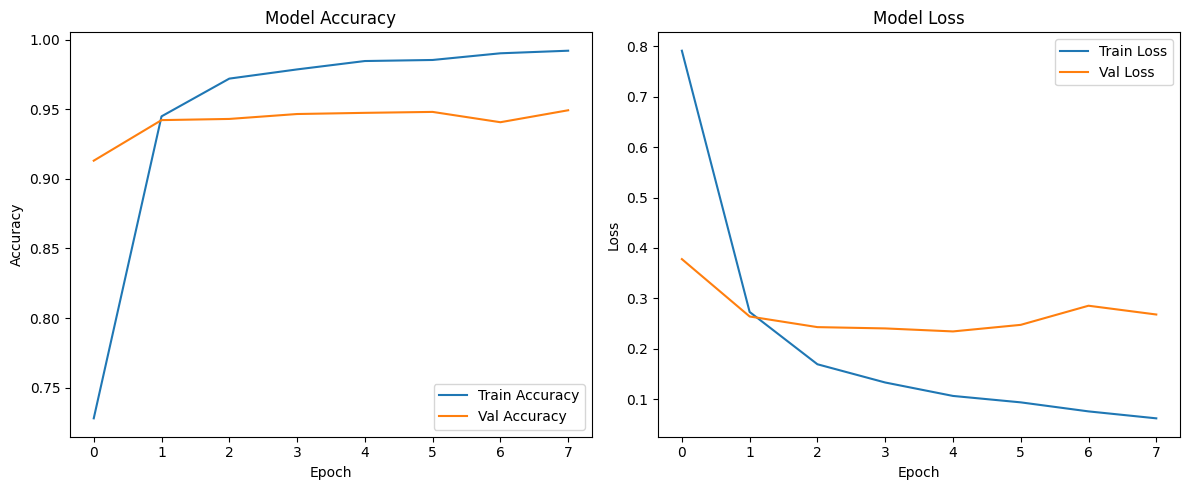

In [ ]:
# Plotting Accuracy & Loss Graph
def plot_training_history(history):
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history)

In [ ]:
# Test Set Prediction
y_pred_prob = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)

232/232 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


In [ ]:
# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.94      2540
           1       0.98      0.98      0.98      2340
           2       0.96      0.93      0.94      2540

    accuracy                           0.95      7420
   macro avg       0.96      0.95      0.95      7420
weighted avg       0.95      0.95      0.95      7420



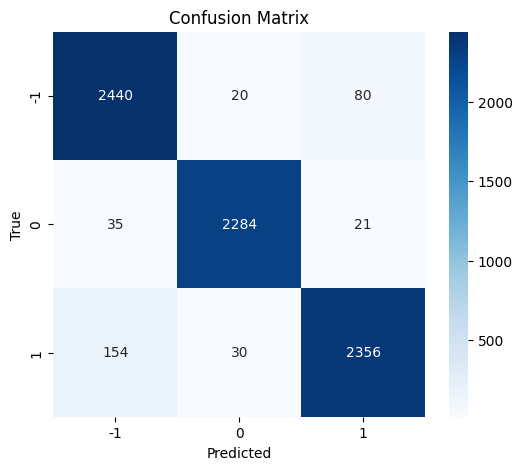

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import joblib

In [ ]:
rf_model = joblib.load("random_forest_model.joblib")
lr_model = joblib.load("log_reg_model.joblib")
lstm_model = tf.keras.models.load_model("lstm_model.keras")

max_len = 100
mapping = {0: "negative", 1: "neutral", 2: "positive"}

def predict_sentiment_rf(text):
    X_tfidf = vectorizer.transform([text])
    pred = rf_model.predict(X_tfidf)[0]
    return mapping.get(pred, "unknown")

def predict_sentiment_lr(text):
    X_tfidf = vectorizer.transform([text])
    pred = lr_model.predict(X_tfidf)[0]
    return mapping.get(pred, "unknown")

def predict_sentiment_lstm(text):
    seq = tokenizer.texts_to_sequences([text])
    pad_seq = pad_sequences(seq, maxlen=100, padding='post', truncating='post')
    pred_prob = lstm_model.predict(pad_seq)
    pred_class = np.argmax(pred_prob, axis=1)[0]
    return mapping.get(pred_class, "unknown")

sample_texts = [
    "I absolutely love this app!",
    "The app performs its functions as intended without any noticeable issues.",
    "I hate this app, it's buggy and crashes all the time."
]

for text in sample_texts:
    print(f"Text: {text}")
    print(f"Random Forest Prediction: {predict_sentiment_rf(text)}")
    print(f"Logistic Regression Prediction: {predict_sentiment_lr(text)}")
    print(f"LSTM Prediction: {predict_sentiment_lstm(text)}")
    print("-" * 50)

Text: I absolutely love this app!
Random Forest Prediction: negative
Logistic Regression Prediction: negative
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
LSTM Prediction: positive
--------------------------------------------------
Text: The app performs its functions as intended without any noticeable issues.
Random Forest Prediction: negative
Logistic Regression Prediction: negative
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
LSTM Prediction: neutral
--------------------------------------------------
Text: I hate this app, it's buggy and crashes all the time.
Random Forest Prediction: negative
Logistic Regression Prediction: negative
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
LSTM Prediction: negative
--------------------------------------------------


In [ ]:
!pip freeze > requirements.txt
!cat requirements.txt

absl-py==1.4.0
accelerate==1.3.0
aiohappyeyeballs==2.4.6
aiohttp==3.11.12
aiosignal==1.3.2
alabaster==1.0.0
albucore==0.0.23
albumentations==2.0.4
ale-py==0.10.1
altair==5.5.0
annotated-types==0.7.0
anyio==3.7.1
argon2-cffi==23.1.0
argon2-cffi-bindings==21.2.0
array_record==0.6.0
arviz==0.20.0
astropy==7.0.1
astropy-iers-data==0.2025.2.10.0.33.26
astunparse==1.6.3
atpublic==4.1.0
attrs==25.1.0
audioread==3.0.1
autograd==1.7.0
babel==2.17.0
backcall==0.2.0
beautifulsoup4==4.13.3
betterproto==2.0.0b6
bigframes==1.36.0
bigquery-magics==0.5.0
bleach==6.2.0
blinker==1.9.0
blis==0.7.11
blosc2==3.1.0
bokeh==3.6.3
Bottleneck==1.4.2
bqplot==0.12.44
branca==0.8.1
CacheControl==0.14.2
cachetools==5.5.1
catalogue==2.0.10
certifi==2025.1.31
cffi==1.17.1
chardet==5.2.0
charset-normalizer==3.4.1
chex==0.1.88
clarabel==0.10.0
click==8.1.8
cloudpathlib==0.20.0
cloudpickle==3.1.1
cmake==3.31.4
cmdstanpy==1.2.5
colorcet==3.1.0
colorlover==0.3.0
colour==0.1.5
community==1.0.0b1
confection==0.1.5
cons==0.4